# Notebook 09 — Segmentación por trayectoria con SAM3 (Etapa 2)

## Idea

Segunda etapa del pipeline _detect-then-segment_ de `plan/detection-segmentation-guide.md`:
toma las cajas `movil` detectadas por YOLO (`notebooks/08_deteccion_yolo.ipynb`) y las convierte
en una máscara por traza usando `Sam3TrackerModel`, la misma clase validada en
`notebooks/07_validacion_prompts_sam3.ipynb` (Paso 4.0).

**Recordatorio de la conclusión del notebook 07**, antes de leer números acá: sobre casos
densos/con cruce, ninguno de los dos baselines da máscaras confiables — el problema es de
**densidad**, no del prompt en sí. Aislado (sin vecina cerca), box-prompt (Baseline A) sí acierta
el objeto (`cambios de identidad`=0) aunque con forma imprecisa; point-prompt (Baseline B) puede
**explotar** a una máscara degenerada que infla el recall de forma engañosa. Por eso acá:
Baseline A se trata como el candidato serio a evaluar, Baseline B se lleva igual (decisión
confirmada en la guía §2: correr ambos, no elegir de antemano) pero como baseline documentado,
con la guarda de máscara degenerada activa para que no gane por default.

## Qué implementa este notebook (guía §4)

- **Paso 4.5a** — Baseline A: SAM3 box-prompt sobre las cajas YOLO.
- **Paso 4.5b** — Baseline B: SAM3 point-prompt (punto = centroide de la misma caja).
- **Paso 4.5c** — extracción sub-píxel por fila (centroide pesado por intensidad), requisito 1.5.
- **Extensión de la tabla de la guía §6** — recall/precision/leakage/área-degenerada +
  diagnóstico de identidad (notebook 07 §6b), sobre **todo** el split de test, no un solo caso.
- **Paso 4.7** — flag de cruces/ambigüedad vía IoU de a pares entre máscaras predichas.
- **Paso 4.6** — reconexión: función de fusión de cajas basada en reglas + una nota honesta
  sobre qué tan lejos llega esta prueba con el esquema de etiquetado actual (ver sección 8).

**Paso 4.8 no está implementado acá a propósito**: requiere el módulo de corrección experta
(WBS Módulo 10, "Almacenamiento de correcciones"), que todavía no existe en este repo. La sección
7 deja las máscaras ambiguas en un DataFrame lucido para conectar ahí el día que exista.

Requisitos: correr `notebooks/08_deteccion_yolo.ipynb` primero (necesita al menos un checkpoint
entrenado en `results/yolo/deteccion_v1*/weights/best.pt`).


---

## 0. Setup


In [ ]:
import sys
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import torch
from PIL import Image

sys.path.append(str(Path("..") / "src"))
from axonal_tracking import etiquetas_deteccion as ed

RAIZ = Path("..").resolve()
DATASETS = RAIZ / "datasets"
TEST_DIR = DATASETS / "test"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Device: {device}")


def norm_uint8(arr):
    """Estira a [0,255] uint8 por percentiles (para visualizar/pasar a PIL, no para metricas).
    Mismo helper que notebook 07."""
    lo, hi = np.percentile(arr, 1), np.percentile(arr, 99.5)
    return np.clip(
        (arr.astype(np.float32) - lo) / max(hi - lo, 1e-6) * 255, 0, 255
    ).astype(np.uint8)


def _to_bf16(inputs):
    """Mismo helper que notebook 07: castea floats al dtype del modelo."""
    return {
        k: (v.to(dtype=torch.bfloat16) if v.is_floating_point() else v)
        for k, v in inputs.items()
    }

Device: mps


## 1. Cargar el detector YOLO ya entrenado (notebook 08)

Se busca el checkpoint **más reciente** en `results/yolo/deteccion_v1*/weights/best.pt` en vez de
apuntar a un nombre de carpeta fijo -- así este notebook no se rompe si se corrió la limpieza de
`results/yolo` (o si el checkpoint viene de la variante 2-clases o de la movers-only, cualquiera
de las dos sirve: aguas abajo sólo se usan las cajas de clase `movil`).


In [2]:
from ultralytics import YOLO

candidatos = sorted(
    (RAIZ / "results" / "yolo").glob("deteccion_v1*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)
assert candidatos, (
    "No hay ningun checkpoint entrenado en results/yolo/deteccion_v1*/weights/best.pt. "
    "Correr notebooks/08_deteccion_yolo.ipynb primero."
)
WEIGHTS_PATH = candidatos[-1]  # el mas reciente
args_run = yaml.safe_load((WEIGHTS_PATH.parent.parent / "args.yaml").read_text())
print(f"Checkpoint YOLO: {WEIGHTS_PATH}")
print(f"  entrenado sobre: {args_run.get('data')}")

yolo = YOLO(str(WEIGHTS_PATH))
CONF_THRES = 0.25  # mismo umbral que la inspeccion cualitativa de notebook 08

Checkpoint YOLO: /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/results/yolo/deteccion_v1/weights/best.pt
  entrenado sobre: /Users/alejandrovalle/Desktop/Posgrado/CEIA/axonal-tracking/datasets/yolo_detection/kymograph_detection.yaml


## 2. Correr YOLO sobre cada kymógrafo de test -> cajas `movil`

Sólo se conservan las cajas de clase `movil` (clase 0): las `estatico` existen para que el
detector aprenda a diferenciarlas quando sus cajas se solapan (ver `etiquetas_deteccion.py`),
pero aguas abajo (cinemática) sólo importan las móviles.

**OJO (verificado en notebook 08)**: predecir de a **una** imagen. Los kymógrafos tienen anchos
muy distintos entre muestras -- si se batchean varias en una sola llamada a `predict()`,
`ultralytics` las redimensiona a un lienzo compartido y distorsiona las más angostas.


In [ ]:
CLASE_MOVIL = ed.CLASE_MOVIL  # 0

muestras = sorted(TEST_DIR.glob("sample_*"))
print(f"{len(muestras)} muestras de test")

escenas = {}  # nombre -> dict(kymo, positions, pixel_scale_um, cajas_yolo)
for s in muestras:
    kymo = np.asarray(ed._leer_kymografo_tif(s / "kymograph.tif"))
    if kymo.ndim == 3:
        kymo = kymo[..., 0]
    positions = pd.read_csv(s / "positions.csv")
    pixel_scale_um = float(
        yaml.safe_load((s / "config.yaml").read_text())["general"]["pixel_scale_um"]
    )

    img_path = DATASETS / "yolo_detection" / "images" / "test" / f"{s.name}.png"
    if not img_path.exists():
        img_path = (
            DATASETS / "yolo_detection_movers" / "images" / "test" / f"{s.name}.png"
        )
    if not img_path.exists():
        print(
            f"  {s.name}: no encuentro el PNG exportado, salteado "
            f"(correr scripts/exportar_etiquetas_deteccion.py)"
        )
        continue

    r = yolo.predict(str(img_path), conf=CONF_THRES, verbose=False)[0]
    cajas = [
        [float(x1), float(y1), float(x2), float(y2)]
        for (x1, y1, x2, y2), cls in zip(
            r.boxes.xyxy.cpu().numpy(), r.boxes.cls.cpu().numpy()
        )
        if int(cls) == CLASE_MOVIL
    ]
    escenas[s.name] = {
        "kymo": kymo,
        "positions": positions,
        "pixel_scale_um": pixel_scale_um,
        "cajas_yolo": cajas,
    }

n_cajas = sum(len(v["cajas_yolo"]) for v in escenas.values())
print(f"{n_cajas} cajas 'movil' detectadas en total sobre {len(escenas)} muestras")

100 muestras de test
704 cajas 'movil' detectadas en total sobre 100 muestras


## 3. Cargar `Sam3TrackerModel` / `Sam3TrackerProcessor`

Mismo checkpoint y misma clase validada en notebook 07 (Paso 4.0) -- `Sam3Model`/`Sam3Processor`
(el de `03_roi_sintetico_sam3.ipynb`) no acepta prompts de punto, así que no sirve para el
Baseline B.


In [4]:
from transformers import Sam3TrackerModel, Sam3TrackerProcessor

MODEL_ID = "facebook/sam3"
processor_tracker = Sam3TrackerProcessor.from_pretrained(MODEL_ID)
model_tracker = (
    Sam3TrackerModel.from_pretrained(MODEL_ID, dtype=torch.bfloat16).to(device).eval()
)

n_params = sum(p.numel() for p in model_tracker.parameters()) / 1e6
print(f"Sam3TrackerModel cargado ({MODEL_ID}): {n_params:.1f}M parametros")

[transformers] You are using a model of type `sam3_video` to instantiate a model of type `sam3_tracker`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

Sam3TrackerModel cargado (facebook/sam3): 458.3M parametros


## 4. Baseline A (box-prompt) y Baseline B (point-prompt)

Todas las cajas de una misma imagen se mandan en **una sola llamada** (batcheadas), no una por
una -- eso habilita `apply_non_overlapping_constraints=True`, que hace un argmax por píxel entre
las máscaras del batch (notebook 07 §6d: elimina el solape _literal_ entre máscaras predichas de
la misma imagen, aunque no arregla la deriva de identidad por sí solo -- es una mejora sin costo,
no una solución completa).

El punto del Baseline B es el **centroide geométrico** de la caja (guía, Paso 4.5b). El notebook
07 §6c ya probó refinarlo al pico de brillo real dentro de una ventana local y no cambió el
resultado -- no se repite ese refinamiento acá.


In [ ]:
def segmentar_boxes(kymo_pil, cajas):
    """Baseline A: box-prompt, todas las cajas de la imagen en una sola llamada
    (permite apply_non_overlapping_constraints -- guia Paso 4.5a / notebook 07 SS6d)."""
    if not cajas:
        return []
    inputs = processor_tracker(
        images=kymo_pil, input_boxes=[cajas], return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        out = model_tracker(**_to_bf16(inputs), multimask_output=False)
    masks = processor_tracker.post_process_masks(
        out.pred_masks.float(),
        inputs["original_sizes"],
        binarize=True,
        apply_non_overlapping_constraints=True,
    )[
        0
    ]  # (N, 1, H, W)
    return [m[0].cpu().numpy() for m in masks]


def segmentar_puntos(kymo_pil, cajas):
    """Baseline B: point-prompt, punto = centroide geometrico de cada caja (guia Paso 4.5b).
    El refinamiento a pico de brillo local (notebook 07 SS6c) no cambio nada, no se repite.
    """
    if not cajas:
        return []
    puntos = [
        [[(x1 + x2) / 2, (y1 + y2) / 2]] for x1, y1, x2, y2 in cajas
    ]  # [objeto][punto][xy]
    etiquetas = [[1] for _ in cajas]  # [objeto][punto], 1 = foreground
    inputs = processor_tracker(
        images=kymo_pil,
        input_points=[puntos],
        input_labels=[etiquetas],
        return_tensors="pt",
    ).to(device)
    with torch.no_grad():
        out = model_tracker(**_to_bf16(inputs), multimask_output=False)
    masks = processor_tracker.post_process_masks(
        out.pred_masks.float(),
        inputs["original_sizes"],
        binarize=True,
        apply_non_overlapping_constraints=True,
    )[0]
    return [m[0].cpu().numpy() for m in masks]


for nombre, d in escenas.items():
    kymo_pil = Image.fromarray(norm_uint8(d["kymo"])).convert("RGB")
    d["masks_A"] = segmentar_boxes(kymo_pil, d["cajas_yolo"])
    d["masks_B"] = segmentar_puntos(kymo_pil, d["cajas_yolo"])

print("Segmentacion (Baseline A y B) terminada para", len(escenas), "muestras.")

Segmentacion (Baseline A y B) terminada para 100 muestras.


### 4.1 Inspección cualitativa de una muestra


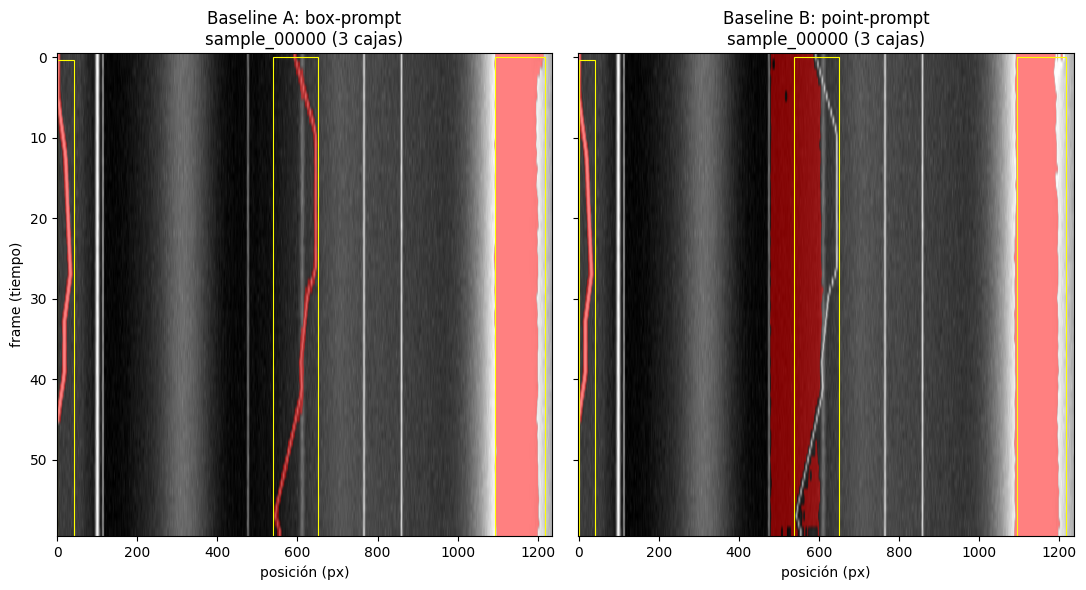

In [ ]:
nombre_ej = next(iter(escenas))
d = escenas[nombre_ej]

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
for ax, masks, title in zip(
    axes,
    [d["masks_A"], d["masks_B"]],
    ["Baseline A: box-prompt", "Baseline B: point-prompt"],
):
    ax.imshow(
        d["kymo"],
        cmap="gray",
        aspect="auto",
        vmin=np.percentile(d["kymo"], 1),
        vmax=np.percentile(d["kymo"], 99.5),
    )
    for caja in d["cajas_yolo"]:
        x1, y1, x2, y2 = caja
        ax.add_patch(
            Rectangle(
                (x1, y1), x2 - x1, y2 - y1, edgecolor="yellow", facecolor="none", lw=0.8
            )
        )
    for mask in masks:
        ax.imshow(
            np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.5, aspect="auto"
        )
    ax.set_title(f"{title}\n{nombre_ej} ({len(d['cajas_yolo'])} cajas)")
    ax.set_xlabel("posición (px)")
axes[0].set_ylabel("frame (tiempo)")
plt.tight_layout()
plt.show()

## 5. Extracción sub-píxel por fila (Paso 4.5c)

Caminar la máscara y tomar sólo la columna entera por fila cuantiza toda velocidad derivada
después (`Δcol/Δrow` se vuelve un cociente de enteros chicos). El requisito 1.5 exige precisión
sub-píxel, así que en vez de eso se toma un **centroide pesado por intensidad real** del
kymógrafo sobre las columnas activas (± un margen), no sólo qué columnas están "prendidas".


In [ ]:
def extraer_subpixel(mask, kymo, margen_px=2):
    """Paso 4.5c: por cada fila (frame) con pixeles activos en la mascara, centroide pesado
    por la intensidad real del kymografo sobre esas columnas +/- un margen. Devuelve un
    DataFrame (frame, col_subpixel) -- subpixel, no columna entera, para no cuantizar la
    velocidad aguas abajo (requisito 1.5)."""
    T, L = kymo.shape[:2]
    kymo2d = kymo if kymo.ndim == 2 else kymo[..., 0]
    filas = []
    for f in range(T):
        cols_activas = np.where(mask[f])[0]
        if len(cols_activas) == 0:
            continue
        c_lo = max(int(cols_activas.min()) - margen_px, 0)
        c_hi = min(int(cols_activas.max()) + margen_px + 1, L)
        ventana = kymo2d[f, c_lo:c_hi].astype(np.float64)
        peso = np.clip(ventana - ventana.min(), 0, None)
        if peso.sum() <= 0:
            col_sub = float(cols_activas.mean())
        else:
            col_sub = float(c_lo + np.average(np.arange(len(ventana)), weights=peso))
        filas.append((f, col_sub))
    return pd.DataFrame(filas, columns=["frame", "col_subpixel"])


# ejemplo sobre la primera mascara no vacia de Baseline A de la muestra de ejemplo
for mask in d["masks_A"]:
    if mask.any():
        polilinea = extraer_subpixel(mask, d["kymo"])
        print(polilinea.head())
        print(f"... {len(polilinea)} filas con posicion sub-pixel extraida")
        break

   frame  col_subpixel
0      0    592.024251
1      1    598.725941
2      2    605.720430
3      3    609.504217
4      4    612.419206
... 60 filas con posicion sub-pixel extraida


## 6. Emparejar con ground truth y evaluar (extiende la tabla de la guía §6)

Mismas métricas que notebook 07 (`recall`, `precision`, `leakage`, guarda de área degenerada,
diagnóstico de identidad `cambios_identidad`/`frac_own`), pero acá sobre **todo** el split de
test en vez de un solo caso hand-picked, y con `leakage` generalizado a "cualquier otra partícula
real", no sólo una vecina nombrada (en una escena de test puede haber más de dos móviles).

Se reusan directamente `ed.cajas_desde_positions` y `ed.mascara_traza` (no se reimplementa la
rasterización) -- ambas ya aplican el espejo L-R correcto documentado al inicio de
`etiquetas_deteccion.py`; usar la convención propia de notebook 07 acá sería exactamente la
trampa fila/columna que la guía (§5) advierte evitar.


In [ ]:
def cajas_gt_movil(positions, pixel_scale_um, shape):
    """Cajas GT, solo clase movil, reusando el exportador (guia Paso 3.1)."""
    return [
        c
        for c in ed.cajas_desde_positions(positions, pixel_scale_um, shape)
        if c.clase == ed.CLASE_MOVIL
    ]


def iou_caja(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(ix2 - ix1, 0.0) * max(iy2 - iy1, 0.0)
    area_a = (a[2] - a[0]) * (a[3] - a[1])
    area_b = (b[2] - b[0]) * (b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def emparejar_con_gt(cajas_pred, cajas_gt, iou_thr=0.3):
    """Empareja cada caja predicha con la caja GT de mayor IoU (>= iou_thr), greedy -- mismo
    criterio que evaluar_deteccion() de notebook 08. Devuelve una lista de indices GT (o None),
    paralela a cajas_pred."""
    usados = set()
    match = []
    for p in cajas_pred:
        mejor_j, mejor_iou = None, iou_thr
        for j, g in enumerate(cajas_gt):
            if j in usados:
                continue
            v = iou_caja(p, (g.x1, g.y1, g.x2, g.y2))
            if v >= mejor_iou:
                mejor_j, mejor_iou = j, v
        if mejor_j is not None:
            usados.add(mejor_j)
        match.append(mejor_j)
    return match


def nearest_particle_per_row(mask, positions_mov, n_frames, pixel_scale_um, L):
    """Para cada fila con pixeles activos: particle_id GT (solo moviles) mas cercano en
    columna -- mismo diagnostico que notebook 07 SS6b, generalizado a N particulas y con el
    espejo L-R correcto (igual que mascara_traza/cajas_desde_positions)."""
    cols_gt = positions_mov.copy()
    cols_gt["col"] = (L - 1) - cols_gt["pos_um"].to_numpy() / pixel_scale_um
    trace = {}
    for f in range(n_frames):
        row_px = np.where(mask[f])[0]
        if len(row_px) == 0:
            continue
        mcol = row_px.mean()
        gf = cols_gt[cols_gt["frame"] == f]
        if len(gf) == 0:
            continue
        d_ = (gf["col"] - mcol).abs()
        trace[f] = (int(gf.loc[d_.idxmin(), "particle_id"]), float(d_.min()))
    return trace


def resumen_identidad(trace, own_id):
    ids = [pid for pid, _ in trace.values()]
    if not ids:
        return {"cambios_identidad": 0, "frac_own": 0.0, "n_filas": 0}
    switches = sum(1 for a, b in zip(ids, ids[1:]) if a != b)
    frac_own = sum(1 for i in ids if i == own_id) / len(ids)
    return {
        "cambios_identidad": switches,
        "frac_own": round(frac_own, 3),
        "n_filas": len(ids),
    }


def evaluar_mascara(pred_mask, gt_propia, gt_otras):
    pred = pred_mask.astype(bool)
    recall = (pred & gt_propia).sum() / max(gt_propia.sum(), 1)
    precision = (pred & gt_propia).sum() / max(pred.sum(), 1)
    leakage = (pred & gt_otras).sum() / max(pred.sum(), 1)
    area_frac = (
        pred.sum() / pred.size
    )  # guarda contra mascaras degeneradas (roi_detect.py)
    return {
        "recall": round(float(recall), 3),
        "precision": round(float(precision), 3),
        "leakage": round(float(leakage), 3),
        "area_frac": round(float(area_frac), 4),
    }


AREA_FRAC_DEGENERADA = (
    0.30  # mascara que cubre >30% del kymografo es sospechosa (ver NB07 SS6f)
)

for nombre, d in escenas.items():
    T, L = d["kymo"].shape[:2]
    d["cajas_gt"] = cajas_gt_movil(d["positions"], d["pixel_scale_um"], (T, L))
    d["match"] = emparejar_con_gt(d["cajas_yolo"], d["cajas_gt"])

filas_eval = []
for nombre, d in escenas.items():
    T, L = d["kymo"].shape[:2]
    px = d["pixel_scale_um"]
    ids_moviles = ed.ids_que_se_mueven(d["positions"], px, 1.0)
    movers = d["positions"][d["positions"]["particle_id"].isin(ids_moviles)]
    masks_gt = {
        pid: ed.mascara_traza(d["positions"], pid, px, (T, L)) for pid in ids_moviles
    }

    for i, j in enumerate(d["match"]):
        if j is None:
            continue  # caja predicha sin GT -- falso positivo de deteccion, fuera de alcance aca
        pid = d["cajas_gt"][j].particle_id
        gt_propia = masks_gt[pid]
        gt_otras = np.zeros((T, L), dtype=bool)
        for otro_pid, m in masks_gt.items():
            if otro_pid != pid:
                gt_otras |= m

        for baseline, masks_key in [("A_box", "masks_A"), ("B_point", "masks_B")]:
            mask = d[masks_key][i]
            m = evaluar_mascara(mask, gt_propia, gt_otras)
            ident = resumen_identidad(
                nearest_particle_per_row(mask, movers, T, px, L), pid
            )
            filas_eval.append(
                {
                    "muestra": nombre,
                    "particle_id": pid,
                    "baseline": baseline,
                    "degenerada": m["area_frac"] > AREA_FRAC_DEGENERADA,
                    **m,
                    **ident,
                }
            )

eval_df = pd.DataFrame(filas_eval)
print(f"{len(eval_df)} pares (caja, baseline) evaluados sobre {len(escenas)} muestras")
eval_df.groupby("baseline")[
    ["recall", "precision", "leakage", "area_frac", "cambios_identidad", "frac_own"]
].mean().round(3)

1244 pares (caja, baseline) evaluados sobre 100 muestras


,recall,precision,leakage,area_frac,cambios_identidad,frac_own
baseline,,,,,,
A_box,0.386,0.735,0.253,0.016,4.116,0.779
B_point,0.361,0.380,0.234,0.068,4.969,0.634


### 6.1 Fracción de máscaras degeneradas por baseline

Notebook 07 §6f encontró que point-prompt a veces "explota" a una máscara que cubre casi toda la
imagen y así gana recall de forma engañosa -- este es el chequeo directo de qué tan seguido pasa
eso en todo el test set, no sólo en un caso.


In [9]:
eval_df.groupby("baseline")["degenerada"].mean().round(3).rename("fraccion_degeneradas")

baseline
A_box      0.000
B_point    0.042
Name: fraccion_degeneradas, dtype: float64

### 6.2 Inspección visual: YOLO vs. predicción SAM3 vs. ground truth, varias muestras

Una figura **por muestra** (no un grid compartido) para que cada kymógrafo se vea a tamaño
legible, con **3 filas separadas, nunca superpuestas en la misma imagen**:

1. **YOLO** -- las cajas `movil` crudas que salieron de la Etapa 1 (notebook 08), sin máscara.
2. **Predicción SAM3** (`BASELINE_VIS`, Baseline A por defecto -- cambiar a `"masks_B"` para
   inspeccionar el punto en su lugar) -- la máscara que produce la Etapa 2 a partir de esas
   mismas cajas.
3. **Ground truth** -- la traza real.

Así se puede seguir el pipeline completo de un vistazo: qué propuso YOLO, qué hizo SAM3 con esa
propuesta, y qué tan lejos quedó de la traza real. Muestras elegidas al azar (semilla fija, para
reproducibilidad) entre las que tienen al menos una caja `movil` detectada.


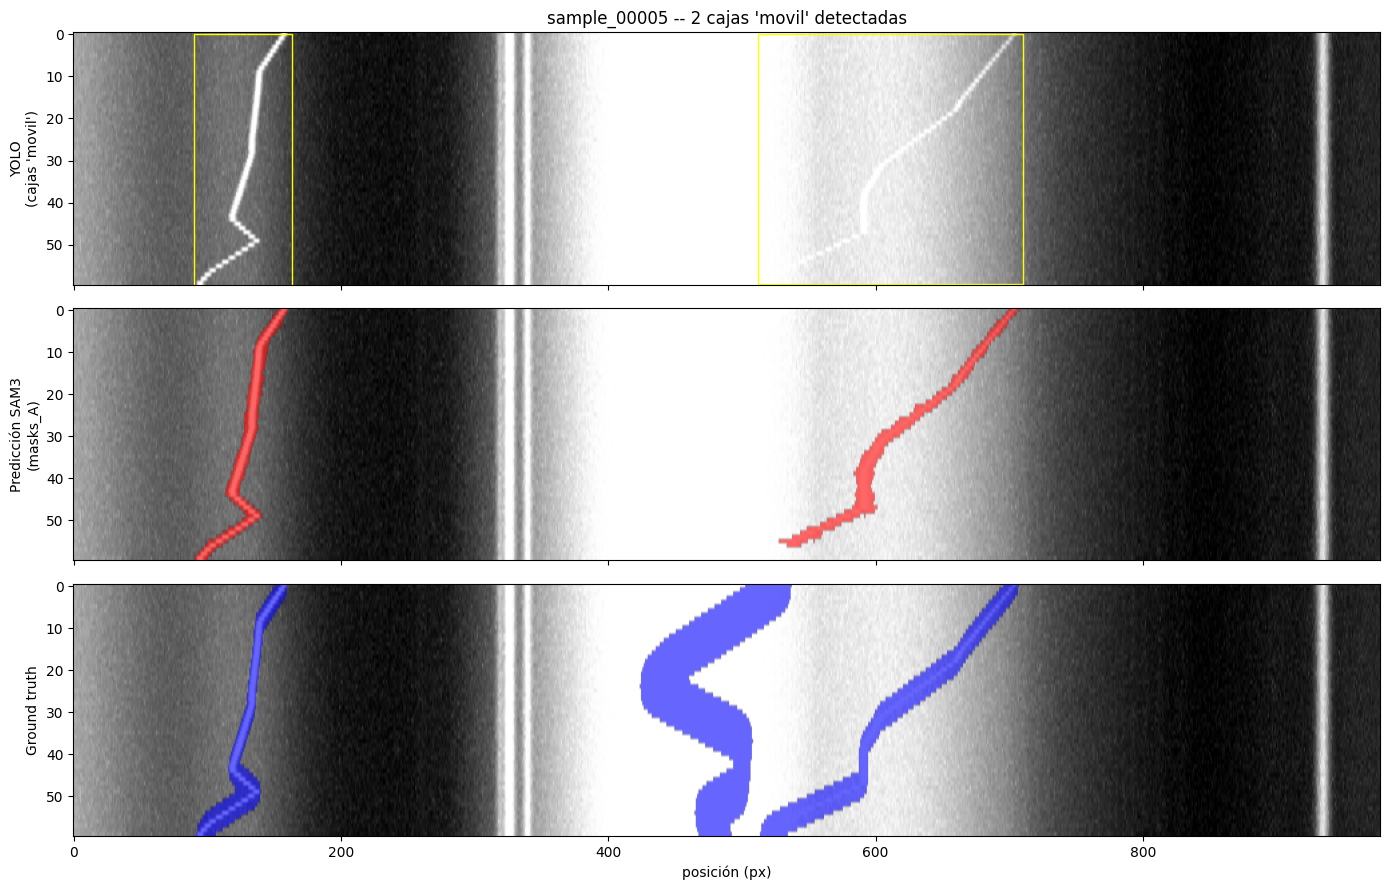

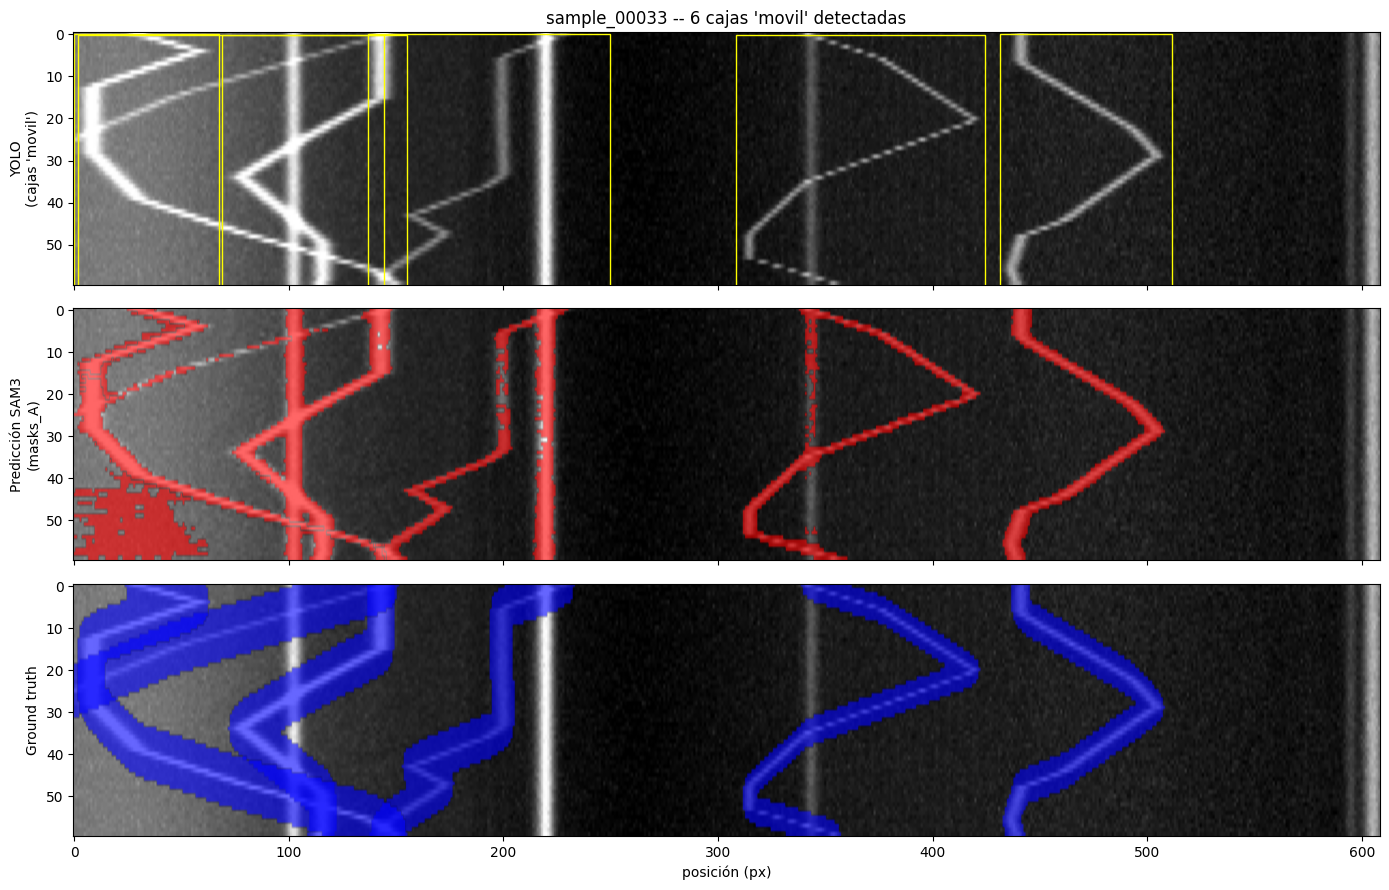

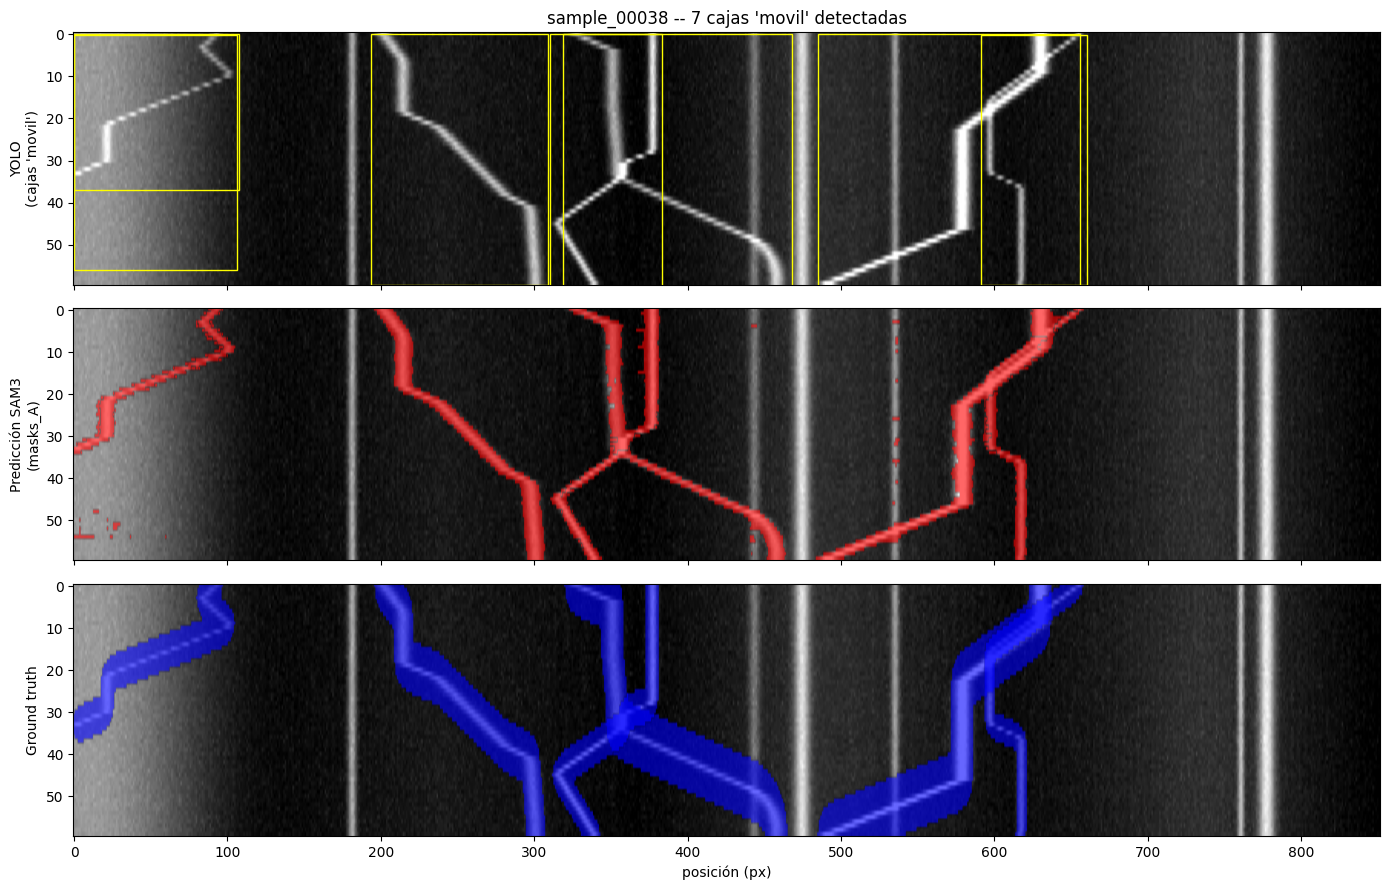

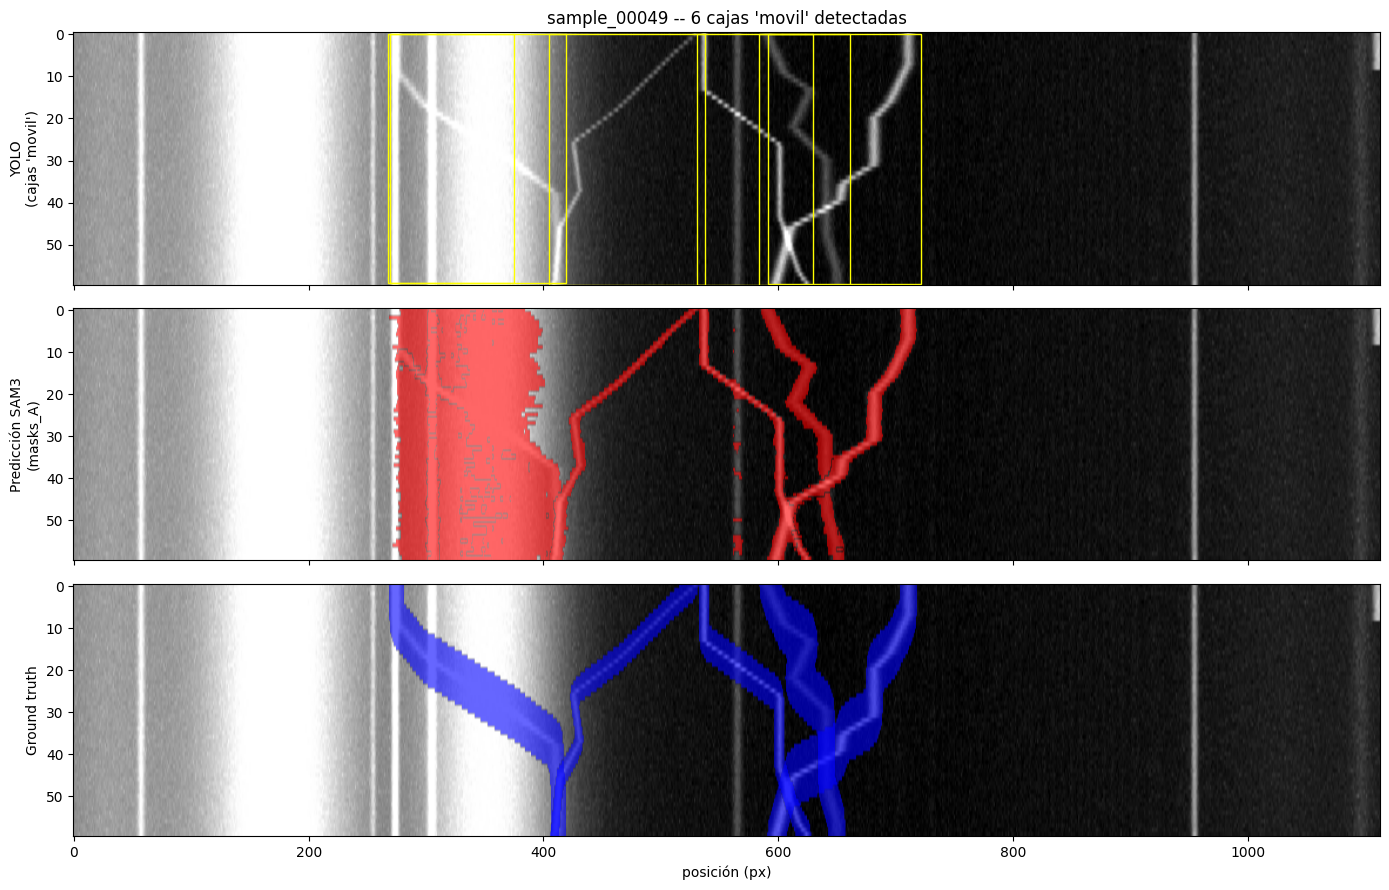

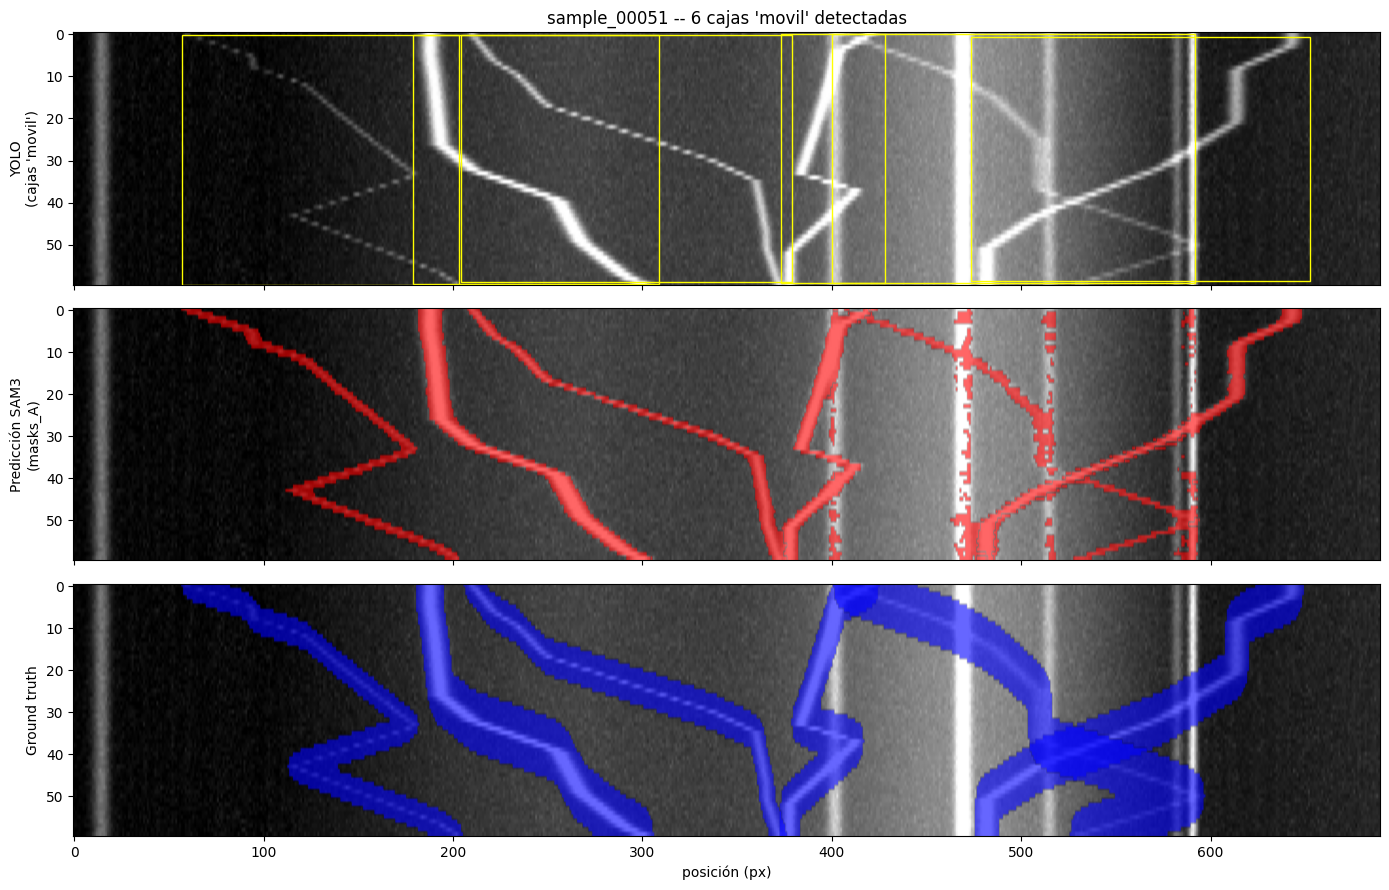

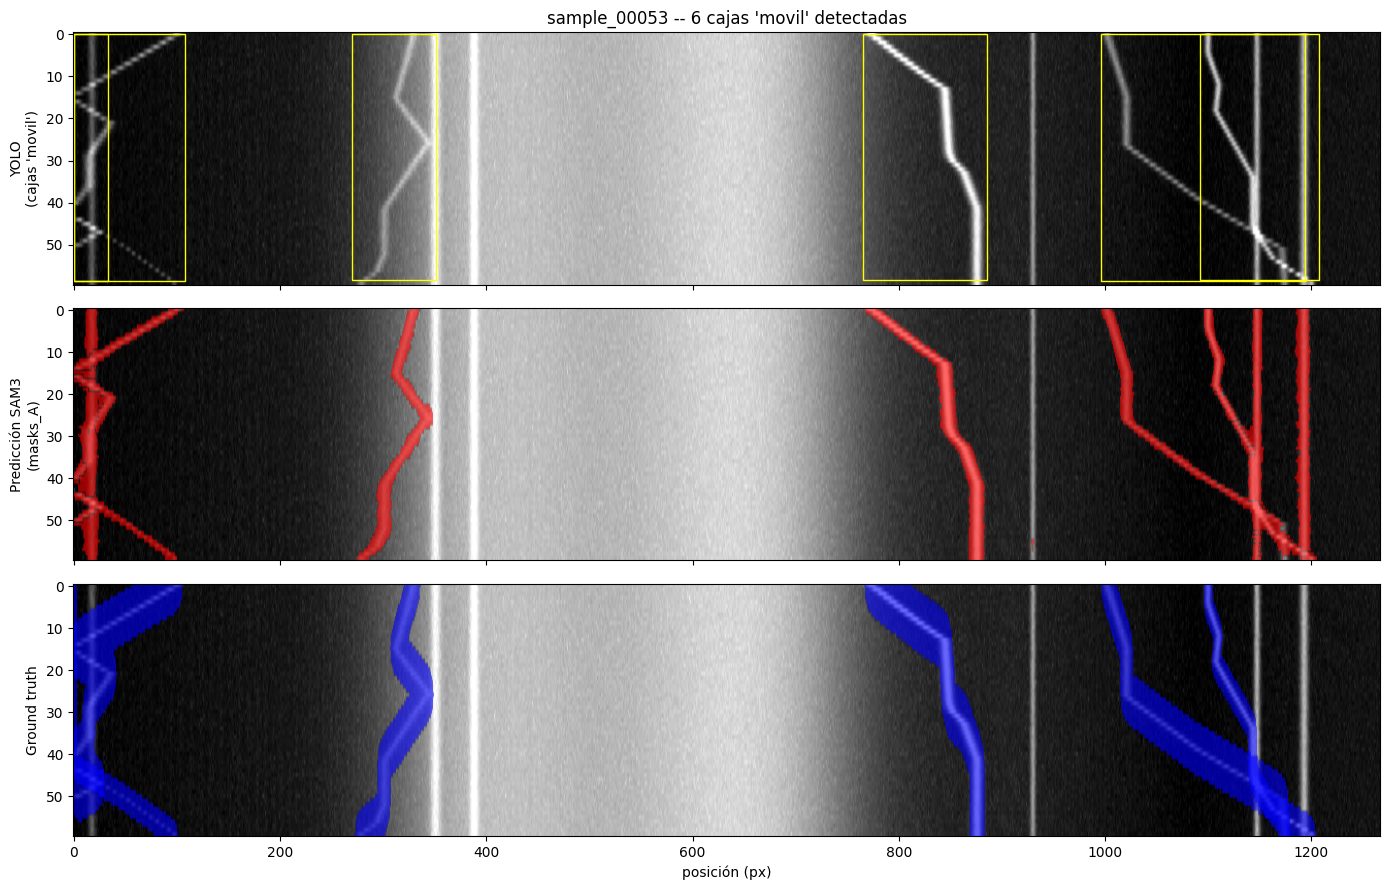

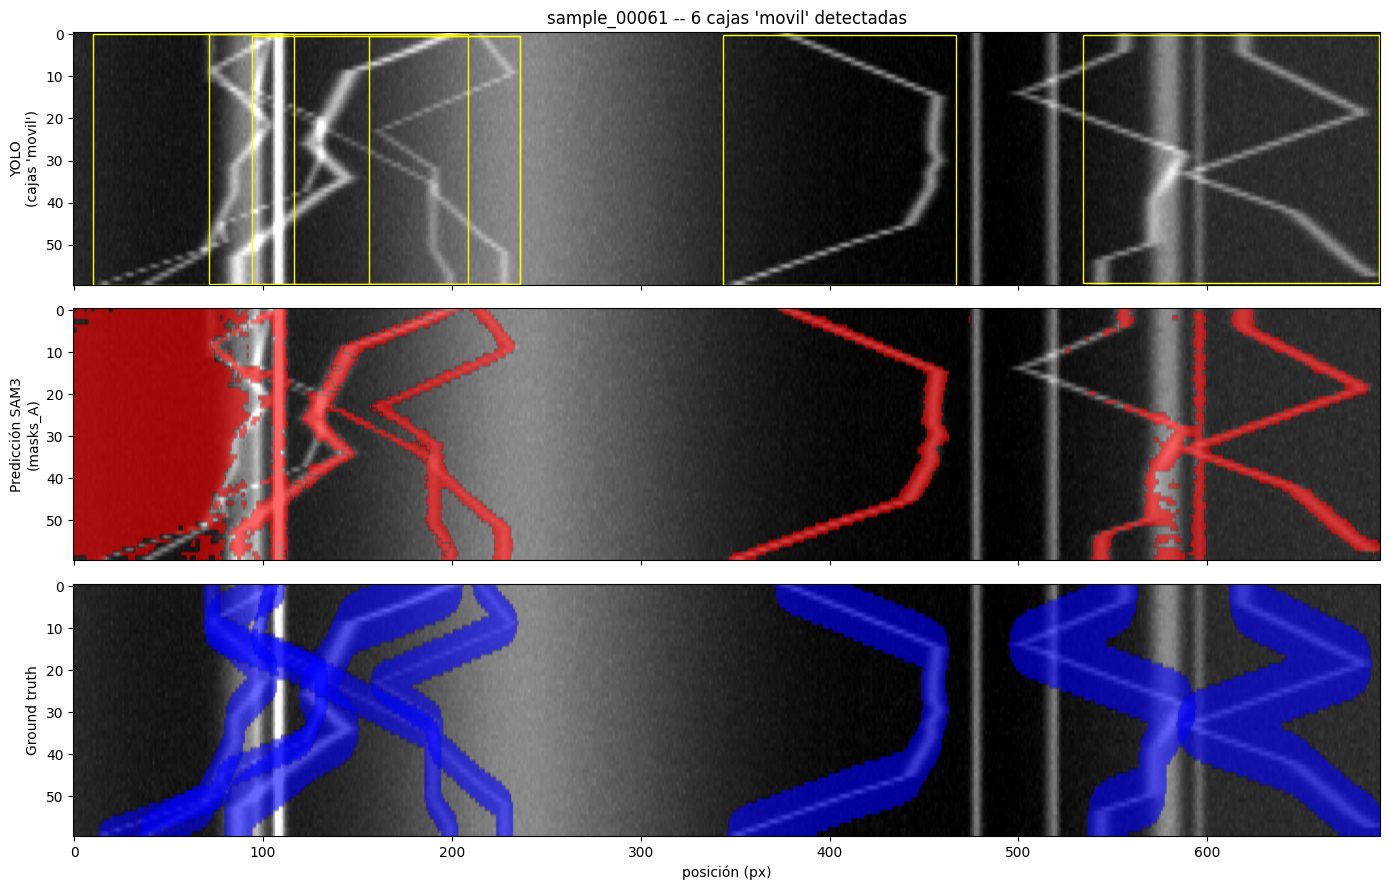

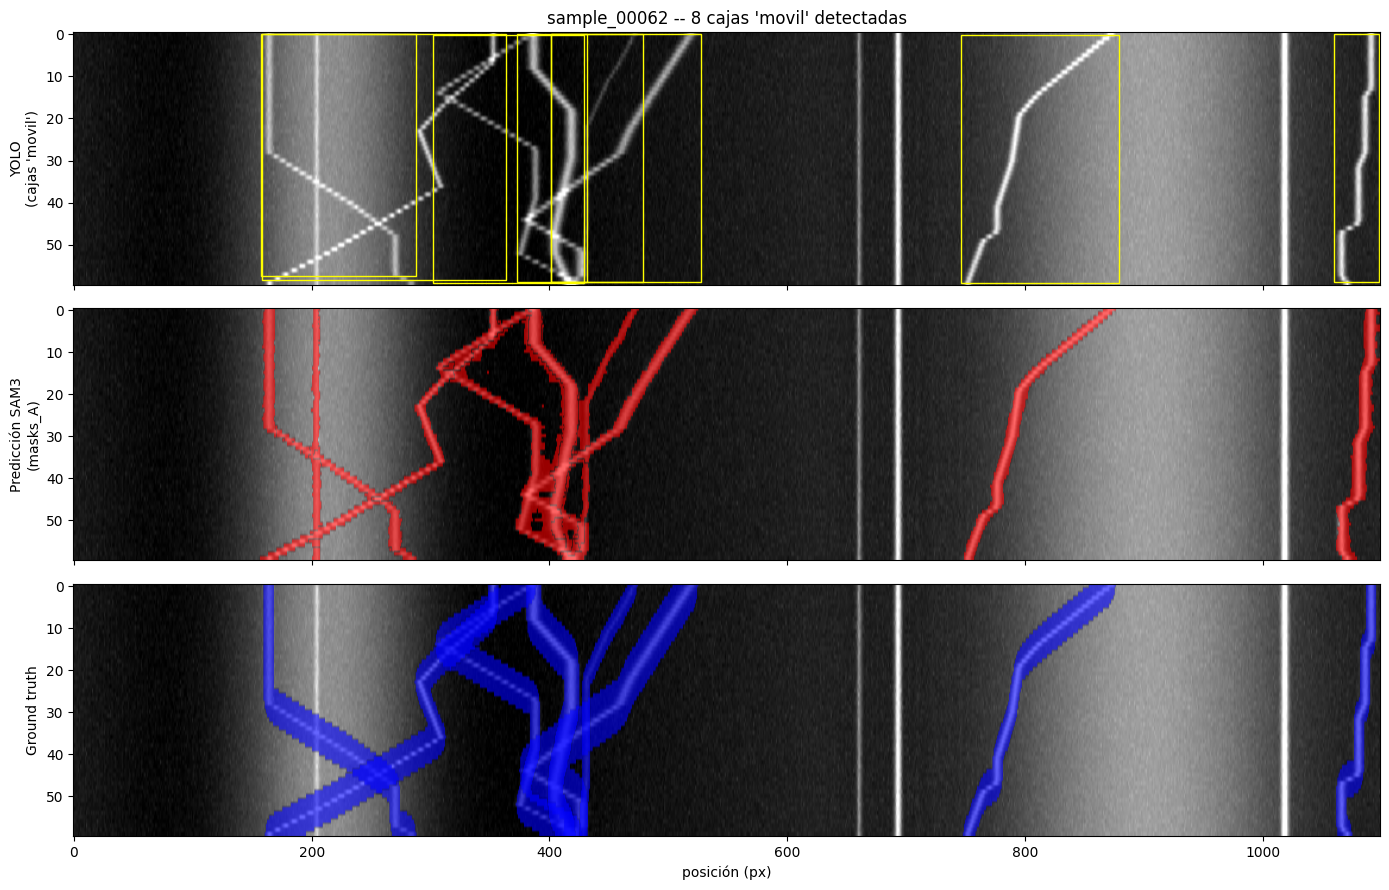

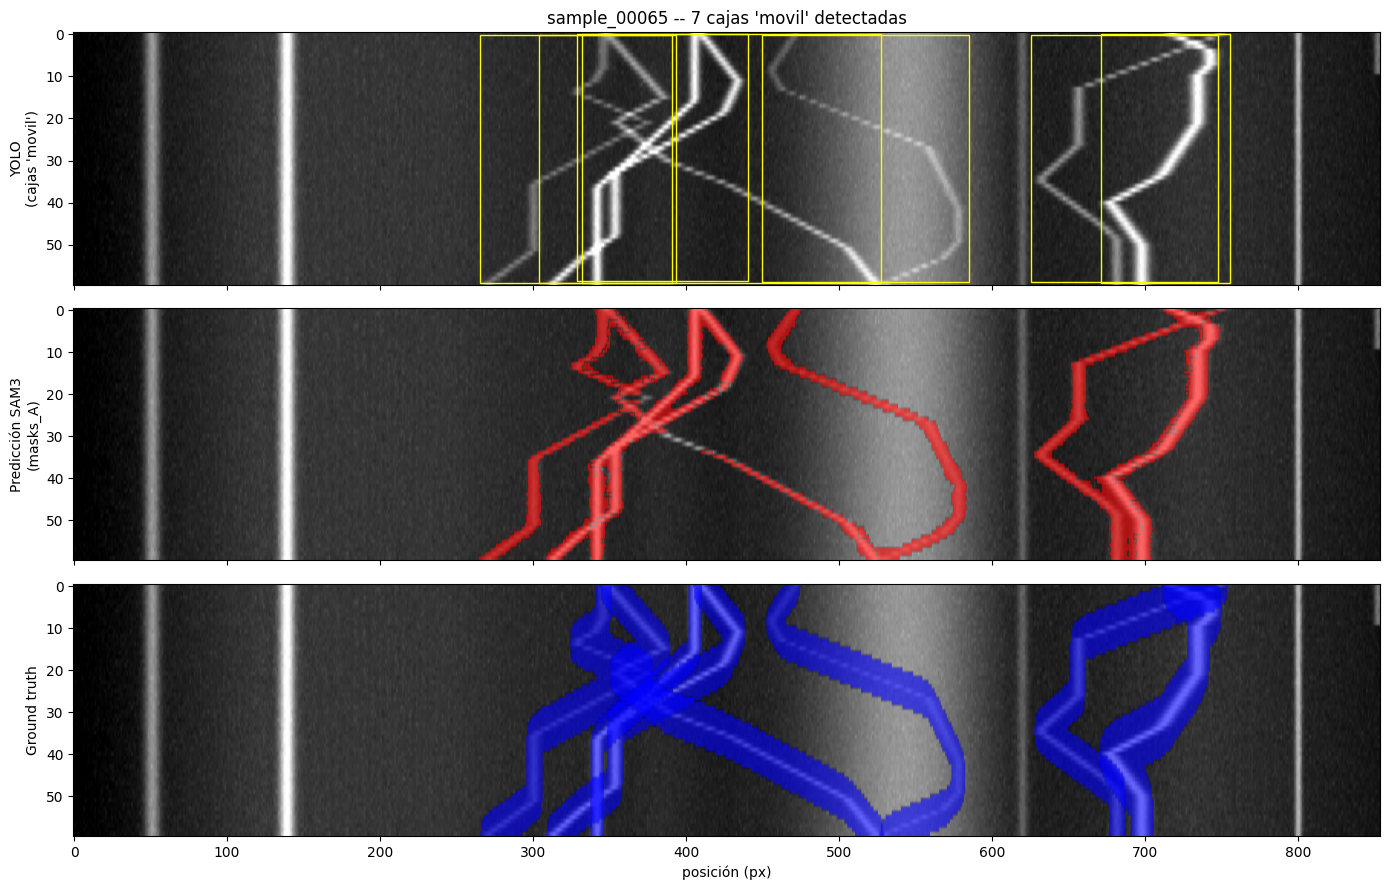

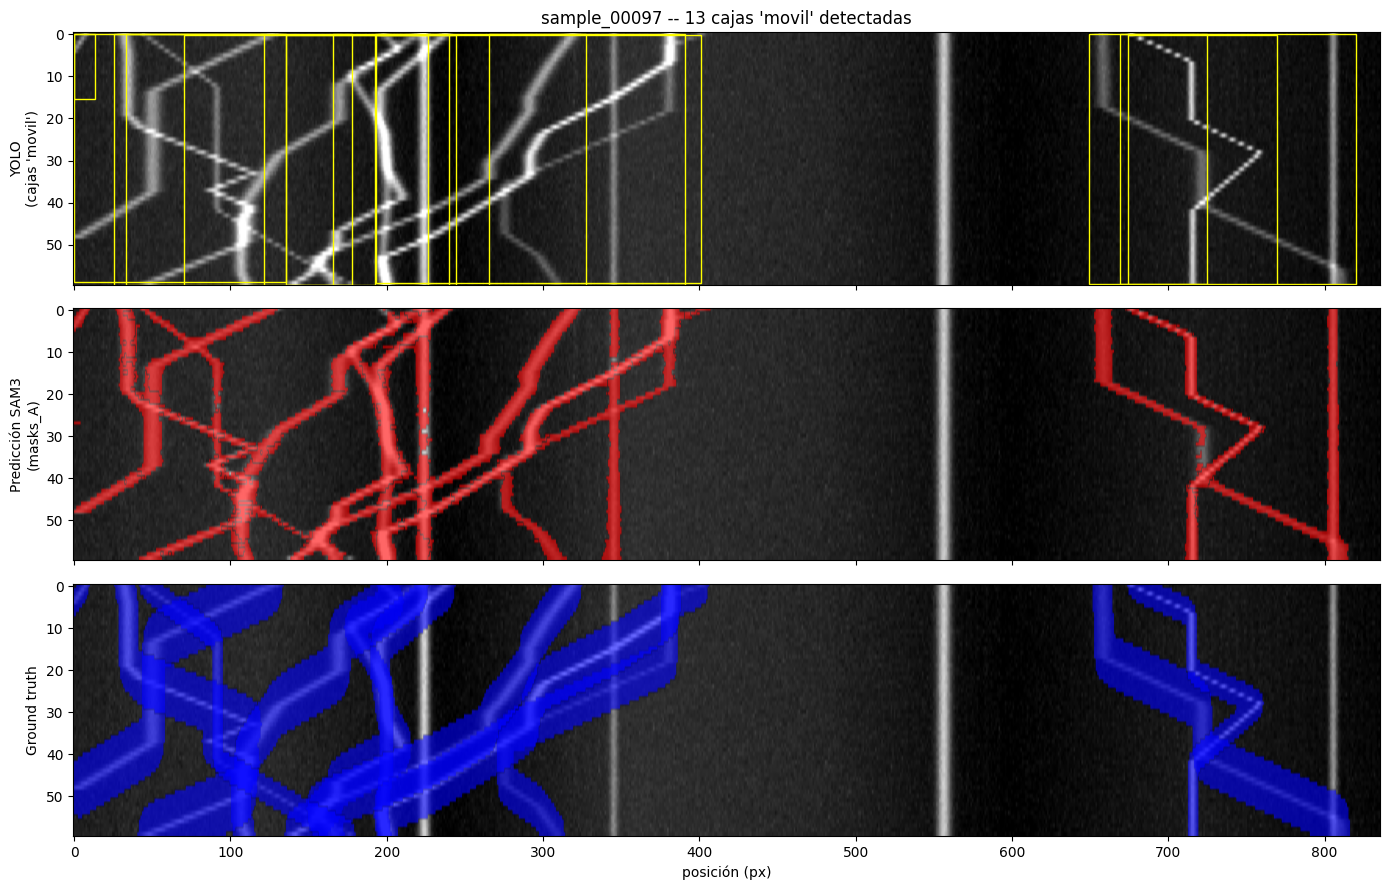

In [ ]:
import random

N_MUESTRAS_VIS = 10
BASELINE_VIS = "masks_A"  # cambiar a "masks_B" para inspeccionar el otro baseline

candidatas = [n for n, d in escenas.items() if d["cajas_yolo"]]
random.seed(0)
muestras_vis = sorted(random.sample(candidatas, min(N_MUESTRAS_VIS, len(candidatas))))

for nombre in muestras_vis:
    d = escenas[nombre]
    kymo = d["kymo"]
    T, L = kymo.shape[:2]
    vmin, vmax = np.percentile(kymo, 1), np.percentile(kymo, 99.5)

    fig, (ax_yolo, ax_pred, ax_gt) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

    # fila 1: SOLO deteccion YOLO (cajas crudas, sin mascara)
    ax_yolo.imshow(kymo, cmap="gray", aspect="auto", vmin=vmin, vmax=vmax)
    for x1, y1, x2, y2 in d["cajas_yolo"]:
        ax_yolo.add_patch(
            Rectangle(
                (x1, y1), x2 - x1, y2 - y1, edgecolor="yellow", facecolor="none", lw=1.0
            )
        )
    ax_yolo.set_ylabel("YOLO\n(cajas 'movil')")
    ax_yolo.set_title(f"{nombre} -- {len(d['cajas_yolo'])} cajas 'movil' detectadas")

    # fila 2: SOLO prediccion SAM3 (sin dibujar el ground truth encima)
    ax_pred.imshow(kymo, cmap="gray", aspect="auto", vmin=vmin, vmax=vmax)
    for mask in d[BASELINE_VIS]:
        ax_pred.imshow(
            np.ma.masked_where(~mask, mask), cmap="autumn", alpha=0.6, aspect="auto"
        )
    ax_pred.set_ylabel(f"Predicción SAM3\n({BASELINE_VIS})")

    # fila 3: SOLO ground truth (sin dibujar la prediccion encima)
    ax_gt.imshow(kymo, cmap="gray", aspect="auto", vmin=vmin, vmax=vmax)
    for caja_gt in d["cajas_gt"]:
        mask_gt = ed.mascara_traza(
            d["positions"], caja_gt.particle_id, d["pixel_scale_um"], (T, L)
        )
        ax_gt.imshow(
            np.ma.masked_where(~mask_gt, mask_gt),
            cmap="winter",
            alpha=0.6,
            aspect="auto",
        )
    ax_gt.set_ylabel("Ground truth")
    ax_gt.set_xlabel("posición (px)")

    plt.tight_layout()
    plt.show()

## 7. Flag de cruces / ambigüedad (Paso 4.7)

Cuando dos máscaras predichas de la **misma** imagen se solapan por encima de un umbral de IoU,
es candidato a cruce o conflicto de segmentación. No se intenta resolver automáticamente --
requisito 1.12 pide marcar los casos ambiguos para revisión experta, no resolverlos en silencio.


In [ ]:
IOU_AMBIGUO = (
    0.10  # cualquier par de mascaras predichas que se solape mas que esto se flaggea
)


def flaggear_cruces(masks, nombre_muestra, particle_ids):
    """Paso 4.7: IoU de a pares entre mascaras predichas de la MISMA imagen. No resuelve nada,
    solo marca (requisito 1.12)."""
    filas = []
    for i, j in itertools.combinations(range(len(masks)), 2):
        inter = (masks[i] & masks[j]).sum()
        union = (masks[i] | masks[j]).sum()
        iou = inter / union if union > 0 else 0.0
        if iou >= IOU_AMBIGUO:
            filas.append(
                {
                    "muestra": nombre_muestra,
                    "particle_id_i": particle_ids[i],
                    "particle_id_j": particle_ids[j],
                    "iou_mascaras": round(float(iou), 3),
                }
            )
    return filas


flags = []
for nombre, d in escenas.items():
    ids_matched = [
        d["cajas_gt"][j].particle_id if j is not None else -1 for j in d["match"]
    ]
    flags += flaggear_cruces(d["masks_A"], nombre, ids_matched)

flags_df = pd.DataFrame(flags)
print(
    f"{len(flags_df)} pares de mascaras (Baseline A) flaggeados como ambiguos (IoU >= {IOU_AMBIGUO})"
)
print(
    "Estas filas son las que deberian llegar al modulo de correccion experta (WBS Modulo 10) --"
)
print(
    "ese modulo todavia no existe en este repo (Paso 4.8), asi que por ahora se deja el DataFrame."
)
flags_df.head(10) if len(flags_df) else flags_df

0 pares de mascaras (Baseline A) flaggeados como ambiguos (IoU >= 0.1)
Estas filas son las que deberian llegar al modulo de correccion experta (WBS Modulo 10) --
ese modulo todavia no existe en este repo (Paso 4.8), asi que por ahora se deja el DataFrame.


""


## 8. Reconexión de trayectorias interrumpidas (Paso 4.6)

**Nota honesta antes del código**: el Paso 3.1 ya construye la caja GT de cada partícula
abarcando todo su rango `[frame.min(), frame.max()]` sobre las filas visibles -- es decir, la
caja GT **ya atraviesa** los huecos de oclusión en vez de partirse en dos. Eso significa que este
esquema de etiquetado actual no genera el material crudo (dos cajas separadas para una misma
partícula) que haría falta para medir reconexión de punta a punta con datos reales del pipeline.
Ese es exactamente el tipo de decisión que la guía (Paso 4.6) pide tomar explícitamente, no
lo que hay que "arreglar" -- se documenta acá en vez de fingir una evaluación que el pipeline
actual no ejercita todavía.

Lo que sí se hace, siguiendo la guía:

1. Reporta, usando la columna `visible` (ground truth ya disponible, sin generar nada nuevo),
   cuántas partículas móviles del test tienen un hueco de visibilidad interno -- para saber qué
   tan relevante sería el problema si Stage 1 llegara a fragmentar una traza en la práctica.
2. Implementa la función de fusión basada en reglas (segunda opción de la guía, análoga en
   espíritu a la recuperación de straddlers de KymoButler) y la valida con un chequeo
   estructural sobre ejemplos sintéticos simples, ya que el pipeline actual no produce cajas
   fragmentadas reales para probarla en contexto.


In [ ]:
def tiene_hueco_visibilidad(positions, particle_id):
    """True si la particula desaparece (visible=False) y vuelve a aparecer DENTRO de su propio
    rango de frames -- la senal que el Paso 4.6 de la guia pide usar como ground truth de
    reconexion (columna `visible`, sin generar nada nuevo)."""
    sub = positions[positions["particle_id"] == particle_id].sort_values("frame")
    vis = sub["visible"].astype(bool).to_numpy()
    if vis.sum() == 0:
        return False
    primero = int(np.argmax(vis))
    ultimo = len(vis) - 1 - int(np.argmax(vis[::-1]))
    return not vis[primero : ultimo + 1].all()


n_con_hueco = 0
n_total_moviles = 0
for d in escenas.values():
    moviles = ed.ids_que_se_mueven(d["positions"], d["pixel_scale_um"], 1.0)
    n_total_moviles += len(moviles)
    n_con_hueco += sum(tiene_hueco_visibilidad(d["positions"], pid) for pid in moviles)

print(
    f"{n_con_hueco}/{n_total_moviles} particulas moviles del test tienen un hueco de visibilidad interno"
)

0/697 particulas moviles del test tienen un hueco de visibilidad interno


In [ ]:
def reconectar_cajas(cajas, max_gap_frames=15, max_offset_px=8):
    """Fusiona dos cajas predichas en una sola si son colineales/adyacentes en posicion y
    estan separadas por un hueco de tiempo chico -- postproceso simple, analogo en espiritu a la
    recuperacion de straddlers de KymoButler pero sin caminar el esqueleto pixel a pixel (guia,
    Paso 4.6, segunda opcion). `cajas`: lista de (x1,y1,x2,y2), se ordenan por tiempo (y1).
    """
    cajas = sorted(cajas, key=lambda c: c[1])
    fusionadas = []
    for c in cajas:
        if fusionadas:
            prev = fusionadas[-1]
            gap = c[1] - prev[3]
            offset = min(abs(c[0] - prev[2]), abs(c[0] - prev[0]), abs(c[2] - prev[2]))
            if 0 <= gap <= max_gap_frames and offset <= max_offset_px:
                fusionadas[-1] = (min(prev[0], c[0]), prev[1], max(prev[2], c[2]), c[3])
                continue
        fusionadas.append(tuple(c))
    return fusionadas


# chequeo estructural (no depende del pipeline de arriba): dos cajas separadas por un hueco
# chico y alineadas en posicion se funden en una; dos cajas lejos en posicion no.
ejemplo_colineal = [(10.0, 0.0, 15.0, 20.0), (12.0, 25.0, 17.0, 40.0)]
ejemplo_lejano = [(10.0, 0.0, 15.0, 20.0), (60.0, 25.0, 65.0, 40.0)]
print("colineal (deberia fusionar en 1) ->", reconectar_cajas(ejemplo_colineal))
print("lejano    (deberia quedar en 2)  ->", reconectar_cajas(ejemplo_lejano))

colineal (deberia fusionar en 1) -> [(10.0, 0.0, 17.0, 40.0)]
lejano    (deberia quedar en 2)  -> [(10.0, 0.0, 15.0, 20.0), (60.0, 25.0, 65.0, 40.0)]


## 9. Conclusión y próximos pasos

Completar con los números reales una vez corrido (`eval_df.groupby("baseline")...` de la sección
6 es la tabla central). Cosas a tener en cuenta al leerlos, heredadas de notebook 07:

- **`leakage`/`recall` bajos no son necesariamente peores que altos** -- una máscara degenerada
  (sección 6.1) puede ganar en recall de forma engañosa. Mirar `cambios_identidad`/`frac_own`
  junto con `degenerada` antes de declarar un baseline mejor que el otro.
- Este test set es **sintético únicamente**. Buena performance acá no descarta el _sim-to-real
  gap_ (Riesgos 1 y 2 del plan formal, guía §5) -- falta correr esto contra una muestra chica de
  datos reales anotados antes de confiar en los números de esta sección para la tesis.
- Si Baseline A zero-shot rinde mal incluso en escenas dispersas (no sólo en las densas), el
  camino recomendado por notebook 07 §7 es, en orden de costo creciente: (a) evitar cruces
  activamente (ya parcialmente cubierto por la sección 7 de este notebook) + extracción sub-píxel
  (sección 5) sobre escenas dispersas; (b) fine-tunear el decoder de SAM3 (encoder congelado); (c)
  Mask2Former end-to-end. No saltar a (b)/(c) sin antes medir (a) sobre el test set completo.
- Actualizar la tabla comparativa de la guía §6 (Baseline A y B como filas separadas) y el
  checklist §7 con los resultados reales de `eval_df` una vez corrido.
